In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import date
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather, InitialConditions

from aquacrop_slovenia import config
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameters_running_rakican import rakican_soil_layers, rakican_curve_number, \
    rakican_readily_evaporable_water, rakican_maize_params, rakican_management, rakican_groundwater, rakican_initial_cond
from aquacrop_slovenia.diagnostics import print_metrics

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
# Set up working directory for outputs
output_dir = config.MODEL_RUNNING_DIR / "testing2"
LOCATION = "rakican"

plant and end dates are set to be the same every year - TODO TEMPORARY!!!

There is no yield observations for 1998 and 2023, so those years are excluded. Year 2017 is excluded due to missing ET data.

In [4]:
simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 4, 20),
        "is_seeding_year": True,
    }
for year in range(1993, 2024) if year not in [1998,2023,2017]]

In [5]:
rakican_temperatures, rakican_eto, rakican_rain = get_station_weather(355) # Rakičan uses ARSO meteo station 355 data

In [6]:
historical_co2 = get_co2_for_aquacrop("historical")

In [7]:
rakican_weather = Weather(
    location=LOCATION,
    temperatures=rakican_temperatures,
    eto_values=rakican_eto,
    rainfall_values=rakican_rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2
)

In [8]:
rakican_maize = Crop(
    name=f"{LOCATION} maize",
    description=f"{LOCATION} maize uncalibrated",
    params=rakican_maize_params
)

In [9]:
rakican_soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} silt loam soil uncalibrated",
    soil_layers=rakican_soil_layers,
    curve_number=rakican_curve_number,
    readily_evaporable_water=rakican_readily_evaporable_water
)

In [10]:
# Create AquaCrop simulation
simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=rakican_maize,
    soil=rakican_soil,
    management=rakican_management,
    initial_conditions=rakican_initial_cond,
    ground_water=rakican_groundwater,
    climate=rakican_weather,
    working_dir=output_dir,
    need_daily_output=True,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False
)

In [11]:
# Run the simulation
results = simulation.run()
seasonal_results = results["season"]

Setting up working directory at: E:\aquacrop\testing2
Running AquaCrop simulation with project file: E:\aquacrop\testing2\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: E:\aquacrop\testing2\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [12]:
seasonal_results

,RunNr,Day1,Month1,Year1,Rain,ETo,GD,CO2,Irri,Infilt,...,HI,Y(dry),Y(fresh),WPet,Bin,Bout,DayN,MonthN,YearN,Project
0,1,1,1,1993,687.4,808.7,1411.0,355.97,0.0,648.1,...,53.6,7.687,8.541,2.29,0.0,0.0,31,12,1993,PROJECT.PRM
1,2,1,1,1994,989.2,776.3,1446.8,357.58,0.0,921.7,...,56.5,9.975,11.083,2.46,0.0,0.0,31,12,1994,PROJECT.PRM
2,3,1,1,1995,924.0,741.8,1284.3,359.53,0.0,848.9,...,56.4,10.808,12.009,2.68,0.0,0.0,31,12,1995,PROJECT.PRM
3,4,1,1,1996,1025.7,696.4,1206.5,361.26,0.0,946.1,...,52.1,10.118,11.243,2.65,0.0,0.0,31,12,1996,PROJECT.PRM
4,5,1,1,1997,691.7,754.4,1276.0,362.43,0.0,671.3,...,56.9,11.435,12.706,3.02,0.0,0.0,31,12,1997,PROJECT.PRM
5,6,1,1,1999,772.4,715.4,1467.9,366.96,0.0,742.6,...,56.8,11.222,12.469,2.85,0.0,0.0,31,12,1999,PROJECT.PRM
6,7,1,1,2000,650.6,827.0,1587.6,368.25,0.0,634.3,...,54.9,7.188,7.987,2.42,0.0,0.0,31,12,2000,PROJECT.PRM
7,8,1,1,2001,643.0,768.9,1427.5,369.65,0.0,620.1,...,56.4,9.173,10.192,2.59,0.0,0.0,31,12,2001,PROJECT.PRM
8,9,1,1,2002,754.1,788.8,1491.2,371.87,0.0,734.1,...,57.0,10.858,12.065,2.73,0.0,0.0,31,12,2002,PROJECT.PRM
9,10,1,1,2003,514.7,857.7,1629.6,374.22,0.0,502.5,...,49.7,3.819,4.243,1.67,0.0,0.0,31,12,2003,PROJECT.PRM


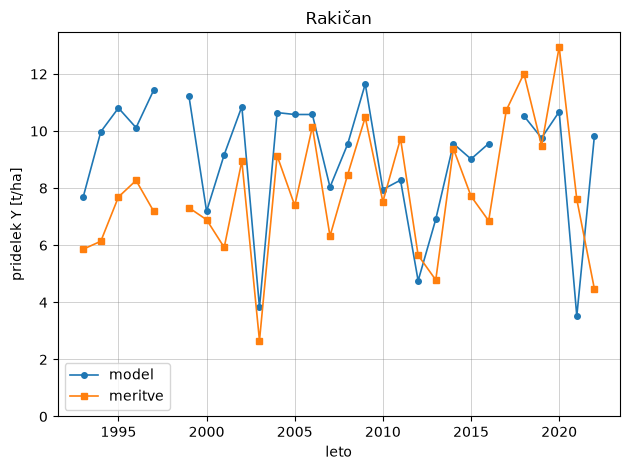

In [13]:
plot_yield_timeseries_comparison(seasonal_results, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)", LOCATION)

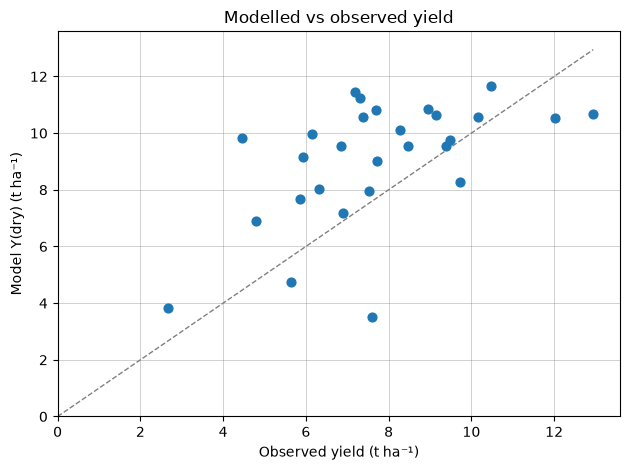

In [14]:
plot_yield_scatter(seasonal_results, get_yield(LOCATION, "grain", "A", "N3"))

In [15]:
print_metrics(seasonal_results, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)", "Grain")

=== Grain ===
  RMSE:       2.4491
  R2:         -0.2359
  NSE:        -0.2359
  KGE:        0.5157
  mKGE:       0.4881
  KGE_r:      0.5469
  KGE_beta:   1.1690
  KGE_alpha:  0.9729
  mKGE_alpha: 0.8322
  Willmott d: 0.6873
  Willmott dr:0.4000


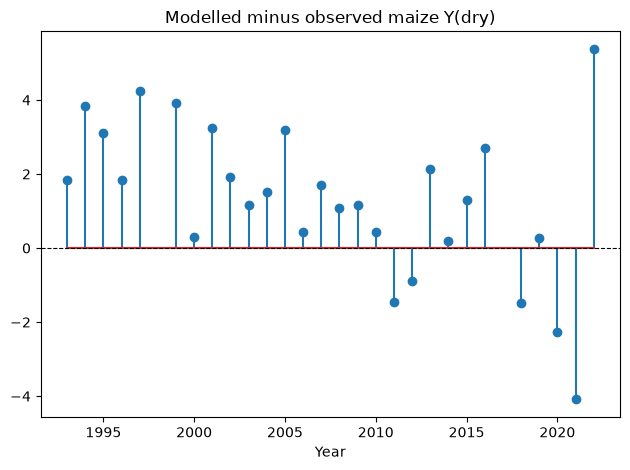

In [16]:
plot_yield_timeseries_residuals(seasonal_results, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)")

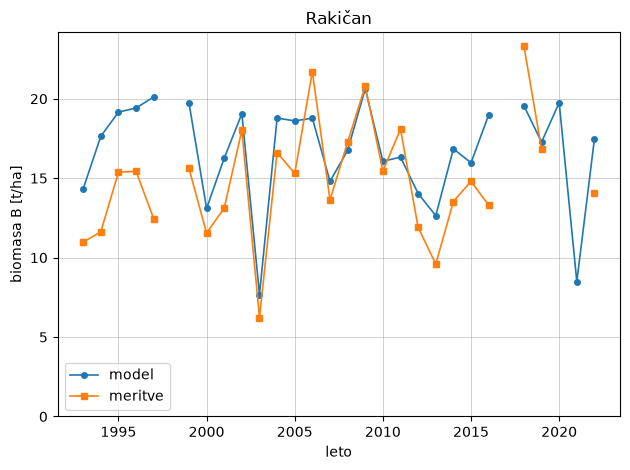

In [17]:
plot_yield_timeseries_comparison(seasonal_results, get_yield_for_comparison(LOCATION, "biomass", "A", "N3"), "BioMass", LOCATION)

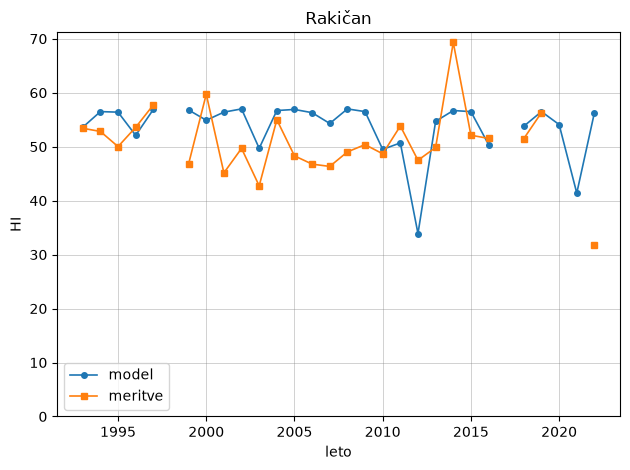

In [18]:
plot_yield_timeseries_comparison(seasonal_results, get_yield_for_comparison(LOCATION, "hi", "A", "N3"), "HI", LOCATION)

In [19]:
results["day"]

,Day,Month,Year,DAP,Stage,WC(1.20),Rain,Irri,Surf,Infilt,...,9_1,ECe10,ECe11,ECe12,Rain_1,ETo,Tmin,Tavg,Tmax,CO2
0,1,1,1993,-9,0,321.3,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
1,2,1,1993,-9,0,320.6,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
2,3,1,1993,-9,0,320.2,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
3,4,1,1993,-9,0,321.3,1.4,0.0,0.0,1.4,...,None,None,None,None,None,None,None,None,None,None
4,5,1,1993,-9,0,322.0,0.6,0.0,0.0,0.6,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,27,12,1993,-9,0,344.7,20.8,0.0,0.0,17.5,...,None,None,None,None,None,None,None,None,None,None
361,28,12,1993,-9,0,333.3,2.0,0.0,0.0,2.0,...,None,None,None,None,None,None,None,None,None,None
362,29,12,1993,-9,0,326.8,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
363,30,12,1993,-9,0,324.2,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None


In [20]:
#results["day"].plot(y="WC(2.00)")

<Axes: >

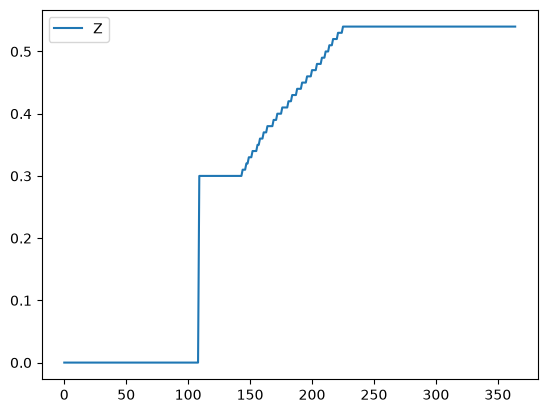

In [21]:
results["day"].plot(y="Z")

<Axes: >

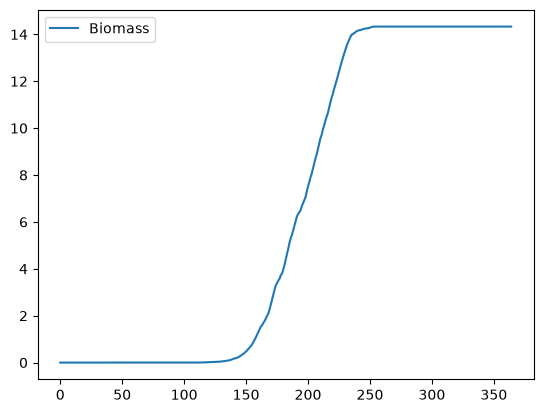

In [22]:
results["day"].plot(y="Biomass")

<Axes: >

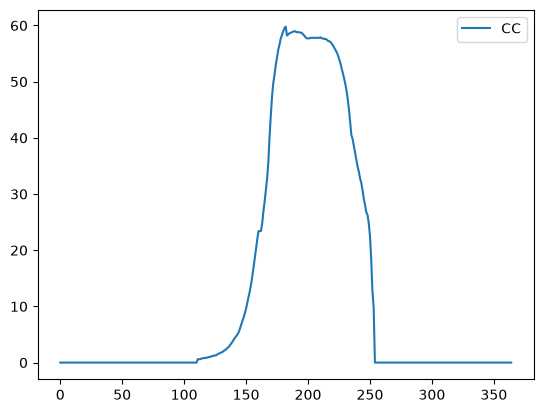

In [23]:
results["day"].plot(y="CC")

<Axes: >

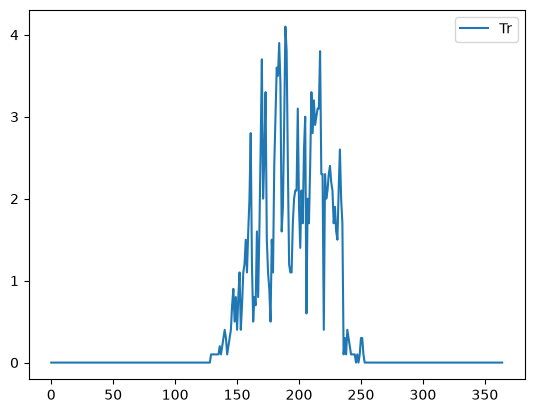

In [24]:
results["day"].plot(y="Tr")

<Axes: >

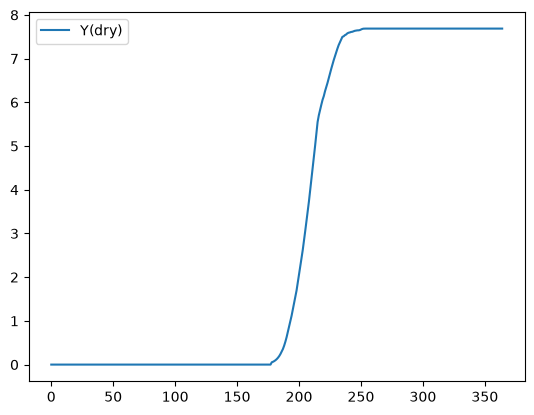

In [25]:
results["day"].plot(y="Y(dry)")